# **Exploratory Data Analysis**

This notebook explores the data to be used in the project and performs any pre-processing necessary to build a machine learning model.

## **Imports**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

## **Introduction**

Temperature control is an important part of the field of motor control. Different industries such
as electric vehicles and manufacturing rely on having motors with high levels of performance,
component longevity, and power efficiency which all rely on effective temperature control of the
motor. Traditionally, temperature monitoring relies on the use of physical sensors which add
cost and latency to controls systems and are typically difficult to incorporate on rotating
components such as stators and permanent magnets. In turn, it is difficult to
capture accurate temperature readings with current manufacturing implementations using a
thermocouple to observe the average surrounding temperature.

![Motor Diagram](imgs/motor_diagram.jpg)

Machine learning can be implemented to predict the temperature of a rotating components to
improve real-time monitoring systems and control loops while reducing the parts needed to
maintain a mechatronic system. Additionally, further steps can be taken to incorporate
optimization through machine learning analysis to improve motor run-time parameters, such as
voltage and speed, to allow for increased torque output while limiting motor temperatures to
safe temperatures.

### **Project Statement**

Develop a machine learning pipeline to test and validate multiple models to accurately predict the rotating permanent magnet temperature in a PM motor.

### **Dataset**

The dataset was uploaded by Dr. Wilhelm Kirchgässner as part of his master’s research in the LEA department focusing on power electronics and electrical drives at Paderborn University and can be found [here.](https://www.kaggle.com/datasets/wkirgsn/electric-motor-temperature) The data is temporal in nature with measurements being taken at a frequency of 2Hz of a electric vehicle PM drive motor being tested at different drive cycles. The features for the study can be seen below:

| Feature        | Description                             |
|----------------|-----------------------------------------|
| u_q            | Voltage in the q-coordinate             |
| u_d            | Voltage in the d-coordinate             |
| i_q            | Current in the q-coordinate             |
| i_d            | Current in the d-coordinate             |
| motor_speed    | Output speed of the motor               |
| torque         | Output torque of the motor              |
| ambient        | Ambient temperature around the motor    |
| coolant        | Temperature of the coolant in the motor |
| stator_yoke    | Temperature of the stator yoke          |
| stator_winding | Temperature of the stator windings      |
| stator_tooth   | Temperature of the stator teeth         |
| pm             | Temperature of the permanent magnet     |
| profile_id     | Id of the current drive cycle           |


## **Basic EDA**

Let's first look at some basic EDA to get a grasp of the data. Let's first load the data:

In [2]:
# Load the data
df = pd.read_csv('data/measures_v2.csv')
df.head()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque,profile_id
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101,17
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417,17
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615,17
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303,17
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197,17


In [3]:
print(f'The dataset has {df.shape[0]} rows and {df.shape[1]} columns')

The dataset has 1330816 rows and 13 columns


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330816 entries, 0 to 1330815
Data columns (total 13 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   u_q             1330816 non-null  float64
 1   coolant         1330816 non-null  float64
 2   stator_winding  1330816 non-null  float64
 3   u_d             1330816 non-null  float64
 4   stator_tooth    1330816 non-null  float64
 5   motor_speed     1330816 non-null  float64
 6   i_d             1330816 non-null  float64
 7   i_q             1330816 non-null  float64
 8   pm              1330816 non-null  float64
 9   stator_yoke     1330816 non-null  float64
 10  ambient         1330816 non-null  float64
 11  torque          1330816 non-null  float64
 12  profile_id      1330816 non-null  int64  
dtypes: float64(12), int64(1)
memory usage: 132.0 MB


After loading the data we can drop any columns that are irrelevant to the study.

In [5]:
# Drop columns that are not needed from initial analysis
cols_to_drop = ['profile_id']
df = df.drop(cols_to_drop, axis=1)
df.head()

,u_q,coolant,stator_winding,u_d,stator_tooth,motor_speed,i_d,i_q,pm,stator_yoke,ambient,torque
0,-0.450682,18.805172,19.086670,-0.350055,18.293219,0.002866,0.004419,0.000328,24.554214,18.316547,19.850691,0.187101
1,-0.325737,18.818571,19.092390,-0.305803,18.294807,0.000257,0.000606,-0.000785,24.538078,18.314955,19.850672,0.245417
2,-0.440864,18.828770,19.089380,-0.372503,18.294094,0.002355,0.001290,0.000386,24.544693,18.326307,19.850657,0.176615
3,-0.327026,18.835567,19.083031,-0.316199,18.292542,0.006105,0.000026,0.002046,24.554018,18.330833,19.850647,0.238303
4,-0.471150,18.857033,19.082525,-0.332272,18.291428,0.003133,-0.064317,0.037184,24.565397,18.326662,19.850639,0.208197


Let's reorder the columns to group features for visual fidelity.

In [6]:
# Reorder columns for ease of analysis
columns_order = [
    'u_q', 
    'u_d', 
    'i_q', 
    'i_d', 
    'motor_speed', 
    'torque',
    'ambient', 
    'coolant', 
    'stator_yoke', 
    'stator_winding', 
    'stator_tooth', 
    'pm'
]
df = df[columns_order]
df.head()

,u_q,u_d,i_q,i_d,motor_speed,torque,ambient,coolant,stator_yoke,stator_winding,stator_tooth,pm
0,-0.450682,-0.350055,0.000328,0.004419,0.002866,0.187101,19.850691,18.805172,18.316547,19.086670,18.293219,24.554214
1,-0.325737,-0.305803,-0.000785,0.000606,0.000257,0.245417,19.850672,18.818571,18.314955,19.092390,18.294807,24.538078
2,-0.440864,-0.372503,0.000386,0.001290,0.002355,0.176615,19.850657,18.828770,18.326307,19.089380,18.294094,24.544693
3,-0.327026,-0.316199,0.002046,0.000026,0.006105,0.238303,19.850647,18.835567,18.330833,19.083031,18.292542,24.554018
4,-0.471150,-0.332272,0.037184,-0.064317,0.003133,0.208197,19.850639,18.857033,18.326662,19.082525,18.291428,24.565397


Next we can check if any of these columns have missing values.

In [7]:
# Check for missing values
df.isna().sum()

u_q               0
u_d               0
i_q               0
i_d               0
motor_speed       0
torque            0
ambient           0
coolant           0
stator_yoke       0
stator_winding    0
stator_tooth      0
pm                0
dtype: int64

Let's numerically explore the distribution of each column.

In [8]:
df.describe()

,u_q,u_d,i_q,i_d,motor_speed,torque,ambient,coolant,stator_yoke,stator_winding,stator_tooth,pm
count,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06,1.330816e+06
mean,5.427900e+01,-2.513381e+01,3.741278e+01,-6.871681e+01,2.202081e+03,3.110603e+01,2.456526e+01,3.622999e+01,4.818796e+01,6.634275e+01,5.687858e+01,5.850678e+01
std,4.417323e+01,6.309197e+01,9.218188e+01,6.493323e+01,1.859663e+03,7.713575e+01,1.929522e+00,2.178615e+01,1.999100e+01,2.867206e+01,2.295223e+01,1.900150e+01
min,-2.529093e+01,-1.315304e+02,-2.934268e+02,-2.780036e+02,-2.755491e+02,-2.464667e+02,8.783478e+00,1.062375e+01,1.807669e+01,1.858582e+01,1.813398e+01,2.085696e+01
25%,1.206992e+01,-7.869090e+01,1.095863e+00,-1.154061e+02,3.171107e+02,-1.374265e-01,2.318480e+01,1.869814e+01,3.199033e+01,4.278796e+01,3.841601e+01,4.315158e+01
50%,4.893818e+01,-7.429755e+00,1.577401e+01,-5.109376e+01,1.999977e+03,1.086035e+01,2.479733e+01,2.690014e+01,4.562551e+01,6.511013e+01,5.603635e+01,6.026629e+01
75%,9.003439e+01,1.470271e+00,1.006121e+02,-2.979688e+00,3.760639e+03,9.159718e+01,2.621702e+01,4.985749e+01,6.146083e+01,8.814114e+01,7.558668e+01,7.200837e+01
max,1.330370e+02,1.314698e+02,3.017079e+02,5.189670e-02,6.000015e+03,2.610057e+02,3.071420e+01,1.015985e+02,1.011480e+02,1.413629e+02,1.119464e+02,1.136066e+02


Each column seems to have a wide range of values that differ from one another. Let's investigate the ranges:

In [9]:
# Find range of values for each column
for col in df.columns:
    range = df[col].max() - df[col].min()
    print(f'{col}: {range:.2f}')

u_q: 158.33
u_d: 263.00
i_q: 595.13
i_d: 278.06
motor_speed: 6275.56
torque: 507.47
ambient: 21.93
coolant: 90.97
stator_yoke: 83.07
stator_winding: 122.78
stator_tooth: 93.81
pm: 92.75


We see that there is a large difference in ranges column to column. This means that we should **scale** our data such that features with large orders of magnitude do not overpower the lower magnitude features during data preprocessing. Let's create some box plots to get a better idea of the distributions, ranges, and outliers.

## **Box Plots**

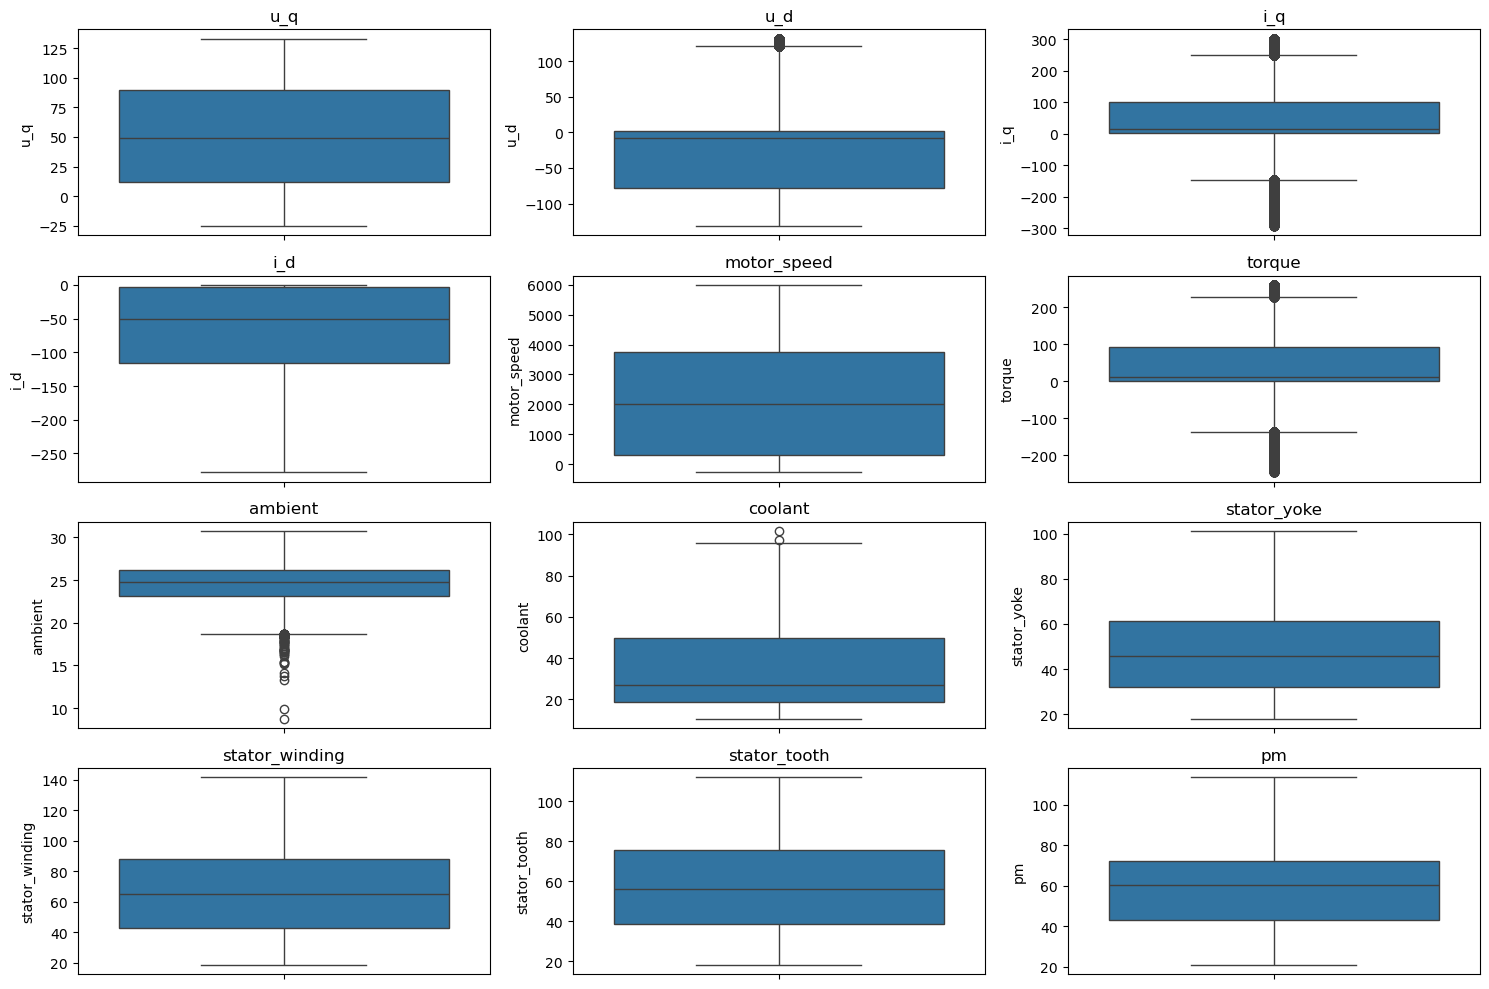

In [10]:
# Create boxplots for each column in the dataframe
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

## **Feature Distributions**

Let's take a look at how the features are distributed to get a sense of their general shapes.

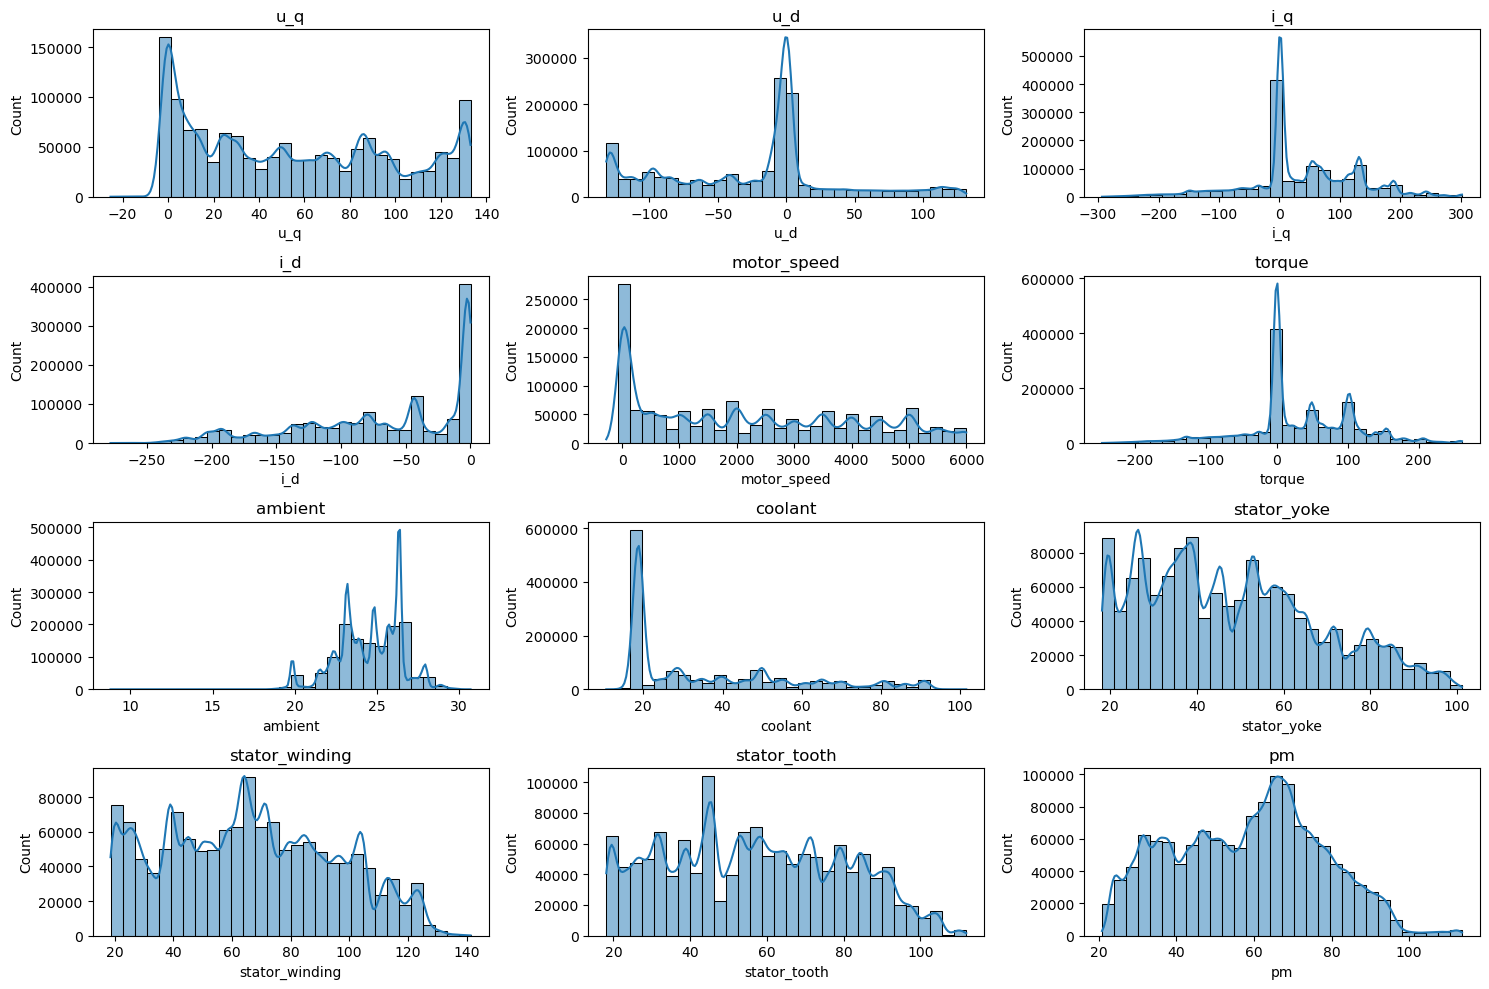

In [11]:
# Create histograms for each column in the dataframe
plt.figure(figsize=(15, 10))
for i, col in enumerate(df.columns, 1):
    plt.subplot(4, 3, i)
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

**Voltage Features (`u_q`, `u_d`)**
- `u_q` ranges mostly between 0 and 125 and is slightly left-skewed
- `u_d` is bimodal and spans both negative and positive values, indicating multiple motor operation modes (e.g., motoring vs. braking)
- Possible opportunity for mode-based feature engineering (e.g., flagging positive vs. negative u_d states)

**Current Features (`i_q`, `i_d`)**
- Both `i_q` and `i_d` are centered near zero with wide distributions extending in both directions
- Strong peaks around zero suggest frequent idle or low-load conditions
- Significant outliers present, reflecting high variability in load conditions
- May benefit from outlier clipping or transformation (e.g., log scaling)

**Mechanical Features (`motor_speed`, `torque`)**
- `motor_speed` is right-skewed, with many low-speed values and a long tail
- `torque` resembles `i_q` in shape, with a strong peak near zero and symmetric spread across positive and negative values
- These features likely interact nonlinearly and are central to motor operation
- Consider creating interaction terms such as torque × motor_speed

**Thermal Features**

***Ambient and Coolant***
- `ambient` is tightly clustered around 25°C with lower-end outliers, possibly indicating cold-start conditions
- `coolant` shows multimodal behavior and wide variability, possibly indicating different operational cooling regimes

***Stator Sensors***
- `stator_yoke`, `stator_winding`, and `stator_tooth` show positive skew and gradual spread across a wide range
- These are likely to correlate strongly with the target `pm` temperature
- Combining them into a "stator heat index" or dropping two of the three feature may be useful

**Target Variable (`pm`)**
- Ranges from ~20°C to ~110°C
- Roughly symmetric with a slight right skew, suggesting good suitability for regression modeling
- Sufficient spread in values to support learning without severe class imbalance (if discretized)

Since we have a very large number of observations, we can take a random sample of a proportion of the data to plot singular observations. Our original data has 1,330,816 observations so lets sample 10% of the data.

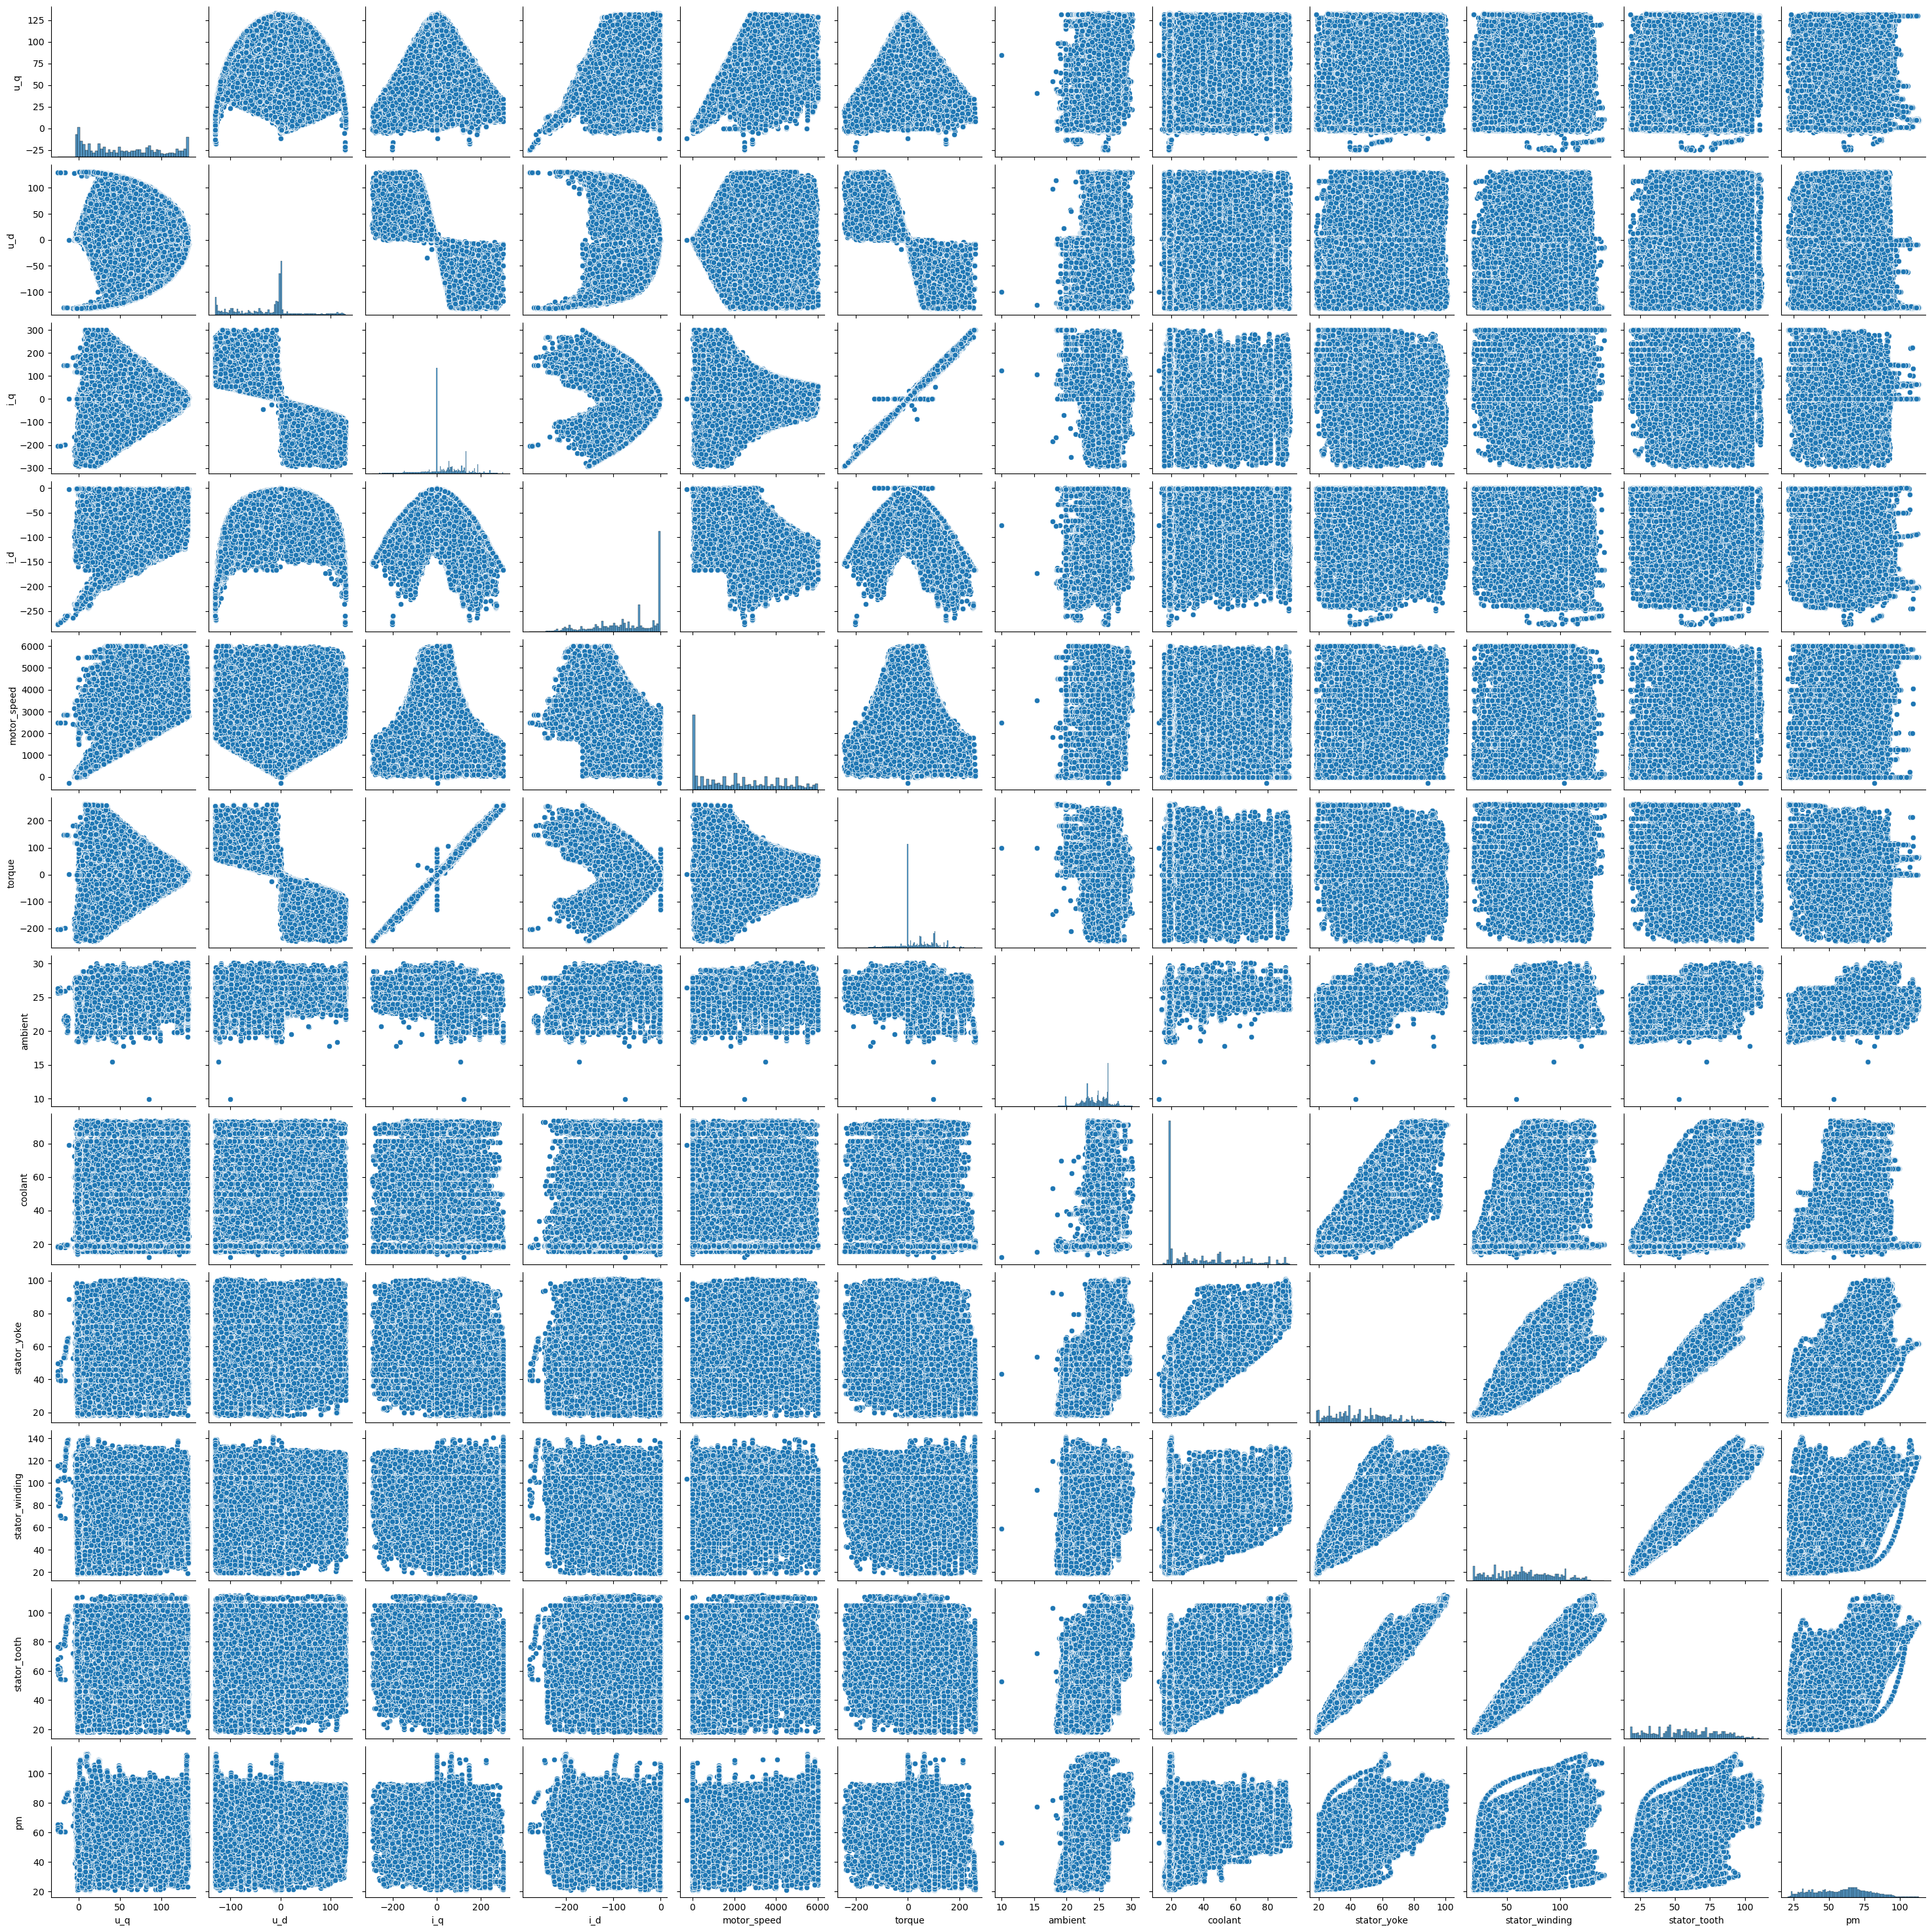

<Figure size 1000x600 with 0 Axes>

In [12]:
# Create a random sample of 25% of the dataframe
df_sample = df.sample(frac=0.10, random_state=42)

# Create a seaborn pairplot
sns.pairplot(df_sample)
plt.figure(figsize=(10, 6))
plt.show()

**Key Relationships with the Target Variable (`pm`)**
- **Strong positive linear relationships** are observed between `pm` and the following variables:
  - `stator_tooth`
  - `stator_winding`
  - `stator_yoke`
- These features show clearly increasing trends in scatterplots with `pm`, suggesting that they are likely the most informative predictors for modeling temperature
- Their predictive value is supported both by linear alignment and by consistent variance with `pm`

**Moderate Predictive Features**
- `coolant` temperature demonstrates a moderate positive relationship with `pm`. While not as tightly coupled as the stator-related variables, it likely contributes to thermal behavior through its influence on heat dissipation
- `ambient` temperature have a potentially weak positive correlation with `pm`. This suggests that although environmental conditions may set boundary conditions for motor temperatures, they do not directly drive significant variance in `pm`

**Feature Redundancy and Multicollinearity**
- Strong linear associations are evident between `stator_tooth`, `stator_winding`, and `stator_yoke`. These features appear to capture similar underlying thermal dynamics within the stator
- This redundancy implies potential multicollinearity, particularly problematic for linear regression models, and can be addressed by:
  - Dimensionality reduction techniques such as Principal Component Analysis (PCA)
  - Dropping redundant features to remove as much multicollinearity as possible

**Non-linear and Complex Interactions**
- The variables `torque` and `motor_speed` display non-linear, potentially parabolic relationships with one another and with `pm`
  - These patterns indicate the presence of interaction effects that are not well captured by simple linear modeling
  - Incorporating polynomial terms or utilizing non-linear models can help capture these interactions

**Features with Weak or No Observable Correlation**
- The electrical variables (`u_q`, `u_d`, `i_q`, `i_d`) have diffuse scatter distributions with respect to `pm`, indicating weak or non-monotonic relationships
- While these features may not directly influence `pm`, they may interact with other variables or affect intermediary physical processes such as the positive linear relation between **torque** and **i_q**

## **Feature Variance**

Feature variance is important to look at as features with low variance might not contribute useful information to the model and features with large variances might dominate others. Let's take a look at the variance of each feature below:

In [13]:
def plot_variance(df: pd.DataFrame):
    """Creates a bar plot of the variance of each feature in the dataset

    Args:
        df (pd.DataFrame): Data 
    """
    
    # Get df variance and sort values in descending order
    var_df = df.var().sort_values(ascending=False)
    
    # Plot the variance of each feature
    plt.figure(figsize=(10, 5))
    sns.barplot(x=var_df.index, y=var_df.values)
    plt.xlabel("Features")
    plt.ylabel("Variance")
    plt.title("Feature Variance")
    plt.xticks(rotation=45)
    plt.show()

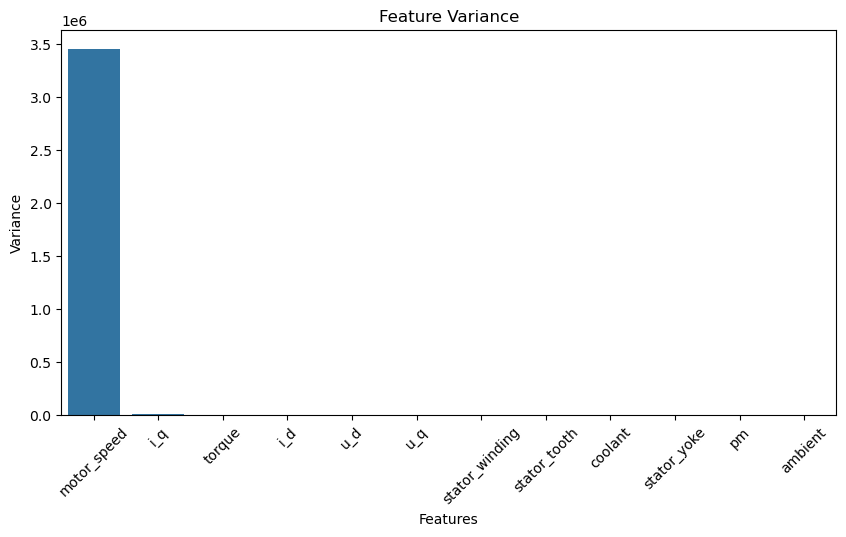

In [14]:
plot_variance(df)

**High Order of Magnitude Variance**
- `motor_speed` has an order of magnitude greater variance as compared to the other features
  - This is due to the wide range of drive cycle operation conditions as well as the wide range of the motor's operational speed
- This may lead to dominance over the other features as the numerical values of speed are simply higher than the values of other features
- Below `motor_speed` is dropped to show the variance in the remaining features

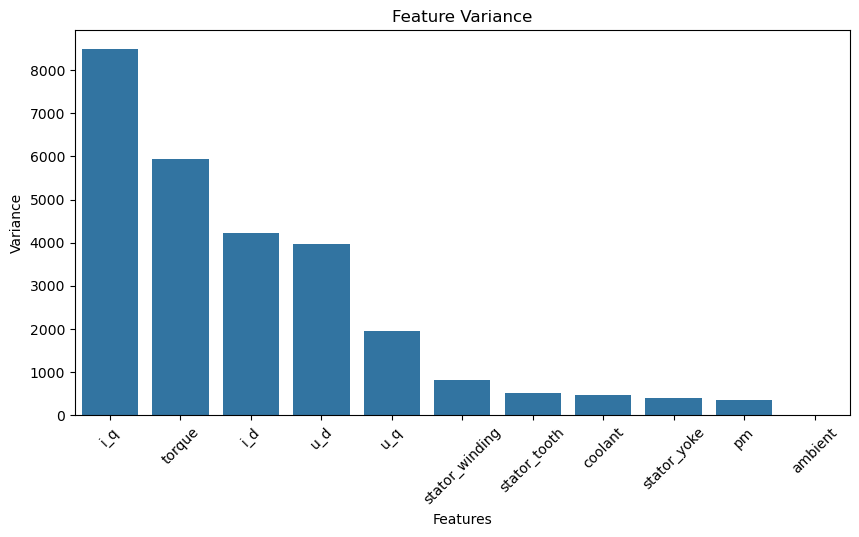

In [16]:
plot_variance(df.drop(['motor_speed'], axis=1))

**High-Variance Features**
- The features with the highest variance are:
  - `i_q` 
  - `torque`
  - `i_d`
  - `u_d`
  - `u_q`
- These features demonstrate substantially greater variability compared to the remaining, suggesting:
  - A wide range of operating conditions for current and torque
  - High dynamic behavior in the motor's electrical input and output states
- These features are likely to dominate unnormalized models and need to be scaled to ensure balanced contributions

**Moderate to Low Variance Features**
- Features such as:
  - `stator_winding`
  - `stator_tooth`
  - `coolant`
  - `stator_yoke`
- These thermal variables exhibit significantly lower variance, which aligns with the expectation that temperatures change more slowly and within narrower operational bounds
- Prior pair plot analysis showed strong **predictive relevance** with respect to `pm`, therefore low variance should not be misinterpreted as low importance in this case

**Lowest Variance Features**
- The features with the lowest variance are:
  - `pm`
  - `ambient`
- The `pm` value having low variance is expected in regulated systems, but it still spans a useful range (~20–110°C) as confirmed in earlier visualizations
- `ambient` temperature has minimal variance, suggesting that most data was collected under relatively stable environmental conditions. It serves mostly as a contextual baseline rather than a primary predictive variable

## **Feature Linear Correlation**

There are many components here that, from a physics standpoint, are likely to have a high degree of correlation. For example `current` and `voltage`, or `motor speed` and `torque` likely have a high degree of interaction with one another. Let's create a linear correlation plot to represent the trends we saw in the plot above in terms of a heatmap.

In [17]:
def plot_corr_heatmap(df: pd.DataFrame):
    """Creates a heatmap of the correlation matrix of the dataframe

    Args:
        df (pd.DataFrame): Data to plot
    """
    
    # Create a correlation matrix and mask the upper triangle
    corr_matrix = df.corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    # Create the heatmap
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        corr_matrix,
        mask = mask,
        annot = True,
        fmt = ".2f",
        cmap = 'coolwarm',
        ax = ax)
    plt.show()

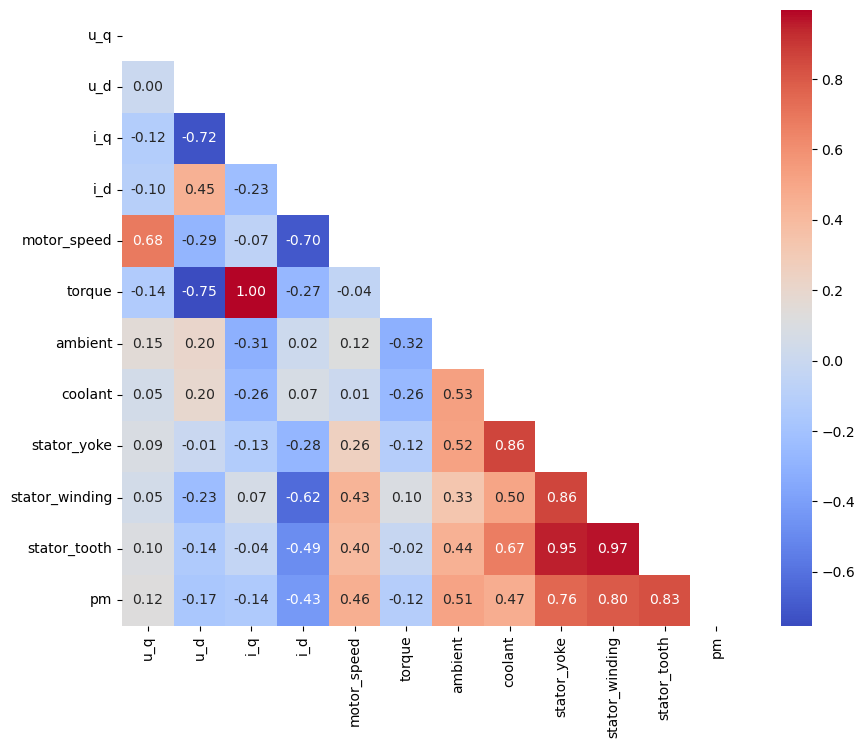

In [18]:
plot_corr_heatmap(df)

**Strong Positive Correlations**
- The strongest positive correlations with the target variable `pm` are:
  - `stator_tooth` (0.83)
  - `stator_winding` (0.80)
  - `stator_yoke` (0.76)
- These results align with previous pair plot insights and confirm that thermal measurements of the stator are key predictors of `pm`
- Notably, these three features are also highly intercorrelated:
  - `stator_tooth` and `stator_winding`: 0.97
  - `stator_tooth` and `stator_yoke`: 0.95
  - `stator_winding` and `stator_yoke`: 0.86
- This indicates a high degree of multicollinearity which may require dimensionality reduction or regularization if used in linear models

**Moderate Correlations with `pm`**
- Other features with moderate positive correlation to `pm`:
  - `ambient`: 0.51
  - `coolant`: 0.47
  - `motor_speed`: 0.46
- These features likely contribute to heating dynamics either through direct thermal exchange (`ambient` and `coolant`) or operational demand (`motor_speed`)

**Weak or Negative Correlations with `pm`**
- `i_q`: -0.14
- `i_d`: -0.43
- `torque`: -0.12
- `u_d`: -0.17
- `u_q`: 0.12

- These features show weak or no linear correlation with `pm`, though they may still influence temperature indirectly or through non-linear interactions
- Their contribution may be better captured using tree-based models or neural networks rather than purely linear approaches

**Other Notable Feature Interactions**
- `torque` and `i_q`: 1.0 — a strong positive relationship, reflecting physical dependency between electromagnetic torque and q-axis current
- `motor_speed` and `u_q`: 0.68 — possibly linked to back-EMF effects and operational control regimes
- `coolant` and `ambient`: 0.53 — suggests partial dependency of coolant temperature on ambient conditions

## **Feature Selection**

This high degree of multicollinearity can cause issues such as overfitting and unstable coefficients when training various machine learning models and it is important to only keep those features that will have a positive contribution to the pipeline. One method of feature selection is to simply drop a feature from a pair of highly correlated features which will help reduce dimensionality and overfitting. However for some models, such as `randomforestregressor` and `XGBoost`, multicollinearity is not much of an issue as the models will inherently handle correlated features by selecting the most important features first. Since we will test a number of different models to see which works the best, we can also see which features `randomforestregressor` and `XGBoost` choose and see if we can discard the least valuable ones (this will be done when testing machine learning models). Another method of feature selection is using Principle Component Analysis (PCA) to reduce the dimensionality of the data and select only those components which have a large contribution to the explainability of the data.

### _**Dropping Highly Correlated Features**_

First let's list out the highly correlated features and try to use some basic reasoning to choose which features can be dropped. We'll set a correlation threshold of 0.85 saying that correlation above this value are considered high. We currently have three temperatures for the stator, one for the stator tooth, winding, and yoke respectively and they are all highly correlated with one another and are located close together in physical proximity. Of these three, we could drop `stator_tooth` and `stator_winding` as they have higher degrees of correlation and less variance as opposed to `stator_yoke`. Both `torque` and `i_q` have very similar correlations and pair-wise distributions, however on average `torque` has higher correlation values so we can drop `torque`. Let's look at the heatmap again with these three features removed.

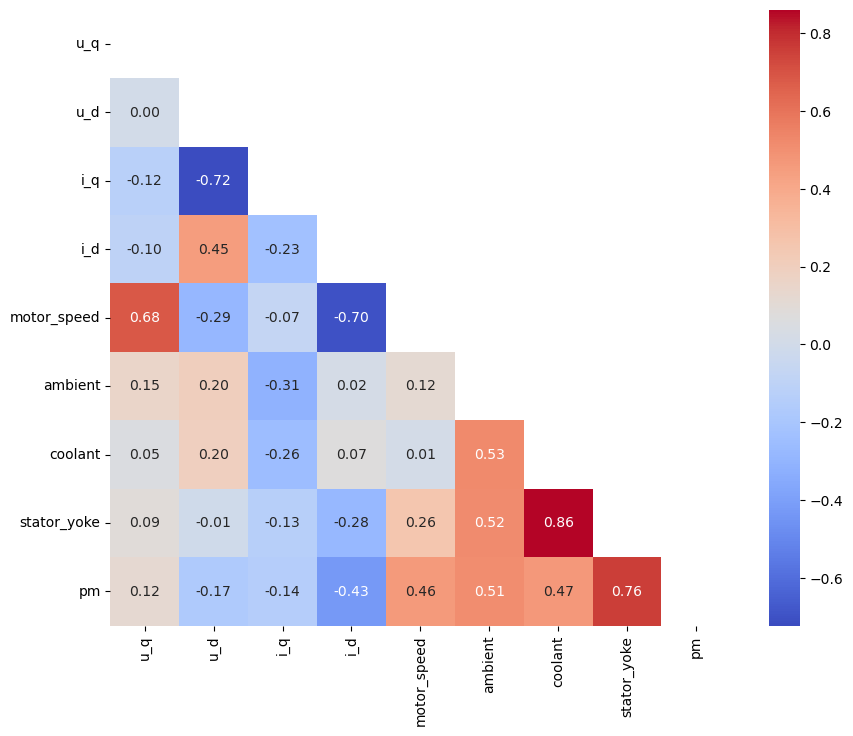

In [19]:
df_subset_1 = df.drop(['torque', 'stator_tooth', 'stator_winding'], axis=1)
plot_corr_heatmap(df_subset_1)

**Remaining High-Degrees of Colinearity**
- `motor_speed` and `u_q`
- `stator_yoke` and `coolant`
- `pm` and `stator_yoke`
- majority of the multi-colinearity has been removed from the data however some pieces still remain
- removing all of high correlated features will lead to too sharp of a data loss as features with variance and importance will be lost
- this should server as a good baseline to test this feature reduction method

### _**Dimensional Reduction Using PCA**_

Another method of inducing dimensional reduction is to use Principle Component Analysis (PCA) to reduce the number of features while keeping their inherit statistical attributes. Let's perform PCA and create a scree plot which will show us the explained variance of each principle component, and allow us to choose what dimension we want to reduce the data to.

In [20]:
def plot_scree(explained_variance: np.array):
    """Plots the scree plot of the explained variance

    Args:
        explained_variance (np.array): Explained variance from PCA
    """
    
    #Create a Scree Plot using Seaborn
    plt.figure(figsize=(10, 6))
    sns.lineplot(
        x = np.arange(1, len(explained_variance) + 1),
        y = explained_variance,
        marker = "o",
        linestyle = "--",
        color = "b"
    )

    # Labels and title
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.title("Scree Plot (Explained Variance vs. Components)")

    # Add horizontal reference lines
    plt.axhline(y=0.90, color="r", linestyle="--", label="90% Variance")
    plt.axhline(y=0.95, color="g", linestyle="--", label="95% Variance")
    
    # Show the plot
    plt.legend()
    plt.show()

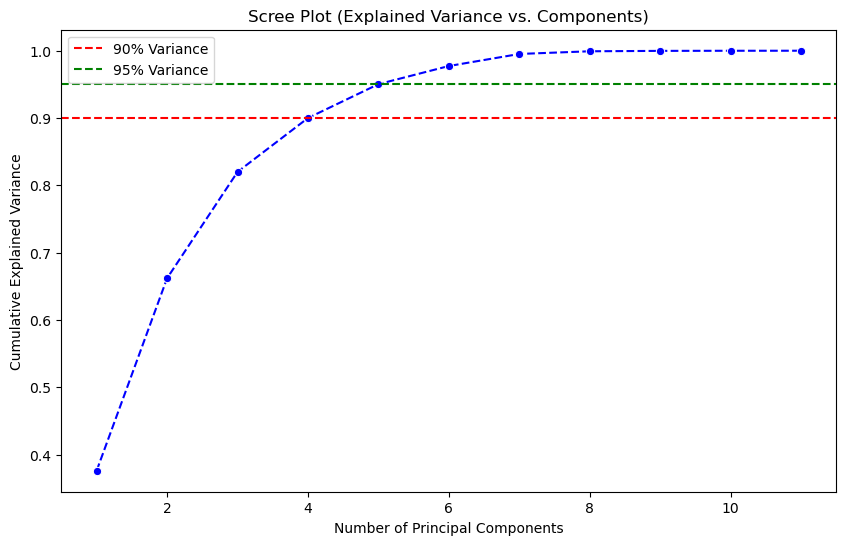

In [21]:
# Create dataset using only the features
feature_df = df.drop('pm', axis=1)

# Standardize the features
scaler = StandardScaler()
feature_df_scaled = scaler.fit_transform(feature_df)

# Create and fit PCA object
pca = PCA()
pca.fit(feature_df_scaled)
explained_variance = np.cumsum(pca.explained_variance_ratio_)

plot_scree(explained_variance)

The scree plot above shows that if we want to explain $95\%$ of the variance in the data we could reduce the data to 5 principle components, and if we want to explain $90\%$ of the data we can reduce it to 4 components instead. Since the difference between $95\%$ and $90\%$ is only one feature, it is more desirable to select 5 feature for the added variance explanation.

## **Conclusion**

When we inspected the **variance** of the features, we saw that `motor_control` had a very high degree of variance which dominates the rest of the features and `ambient` has a very low degree meaning that it does not contribute much information as the ambient temperatures will not vary much observation to observation. As such we concluded that the data will need to be **scaled** and `ambient` can be **dropped** from the data set. After taking a look a the correlations, we saw that there were many features which had high degree of correlation meaning the dataset had a good amount of multicollinearity. We deduced that `torque`, `stator_teeth`, and `stator_winding` could be **dropped** from the dataset to reduce multicollinearity. In the end if we follow this method, we would have 8 features. After applying PCA the data we observed that if we want to explain $95\%$ of the data we can reduce the dimensionality to 5 principle component, three less than the other method. There is no true way to determine which method is better as of yet. The next step is to experiment with a few machine learning models too determine which preprocessing method leads to better results.